Trial 1/30
Trial 2/30
Trial 3/30
Trial 4/30
Trial 5/30
Trial 6/30
Trial 7/30
Trial 8/30
Trial 9/30
Trial 10/30
Trial 11/30
Trial 12/30
Trial 13/30
Trial 14/30
Trial 15/30
Trial 16/30
Trial 17/30
Trial 18/30
Trial 19/30
Trial 20/30
Trial 21/30
Trial 22/30
Trial 23/30
Trial 24/30
Trial 25/30
Trial 26/30
Trial 27/30
Trial 28/30
Trial 29/30
Trial 30/30

Final statistics
--------------------------
Mean = 0.9965350291474023
Std  = 0.0010714618152118018
Min  = 0.9930651701203693
Max  = 0.9979927733758055


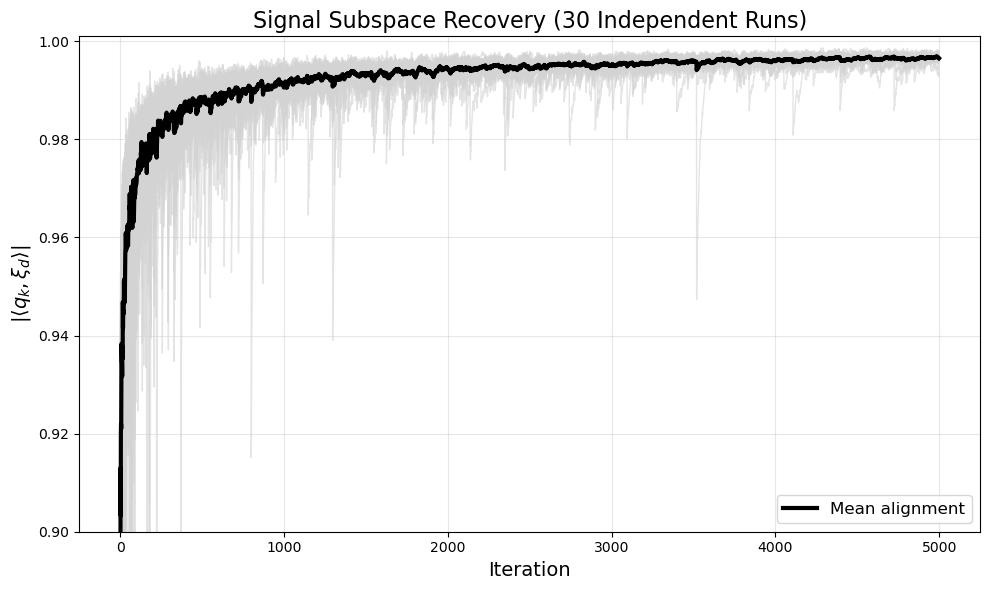

<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Parameters
# =====================================================

d = 50

R = 500              # informative tokens
N = 500              # nuisance tokens

theta = 2.0
beta = 1.0

T = 5000

eta0 = 0.5
alpha = 0.6

num_trials = 30

# =====================================================
# One run
# =====================================================

def run_trial(seed):

    np.random.seed(seed)

    # latent signal
    xi = np.random.randn(d)
    xi /= np.linalg.norm(xi)

    # initialization
    q = np.random.randn(d)
    q /= np.linalg.norm(q)

    alignment = np.zeros(T)

    for t in range(T):

        eta = eta0 / ((t + 1) ** alpha)

        # -----------------------------------------
        # Generate tokens
        # -----------------------------------------

        X_inf = theta * xi + np.random.randn(R, d)

        X_noise = np.random.randn(N, d)

        X = np.vstack([X_inf, X_noise])

        # -----------------------------------------
        # Softmax weights
        # -----------------------------------------

        logits = beta * (X @ q)

        logits -= np.max(logits)

        weights = np.exp(logits)

        a = weights / np.sum(weights)

        # -----------------------------------------
        # Attention output
        # -----------------------------------------

        f = np.sum(a[:, None] * X, axis=0)

        # -----------------------------------------
        # Gradient
        #
        # g = 2 beta sum_i
        #     a_i <x_i,f> (x_i-f)
        # -----------------------------------------

        inner = X @ f

        g = (
            2.0
            * beta
            * np.sum(
                a[:, None]
                * inner[:, None]
                * (X - f),
                axis=0
            )
        )

        # -----------------------------------------
        # Projection step
        # -----------------------------------------

        q_new = q + eta * g

        q = q_new / np.linalg.norm(q_new)

        alignment[t] = abs(np.dot(q, xi))

    return alignment


# =====================================================
# Run experiments
# =====================================================

all_runs = []

for seed in range(num_trials):

    print(f"Trial {seed+1}/{num_trials}")

    curve = run_trial(seed)

    all_runs.append(curve)

all_runs = np.array(all_runs)

# =====================================================
# Statistics
# =====================================================

mean_curve = np.mean(all_runs, axis=0)

final_vals = all_runs[:, -1]

print("\nFinal statistics")
print("--------------------------")
print("Mean =", np.mean(final_vals))
print("Std  =", np.std(final_vals))
print("Min  =", np.min(final_vals))
print("Max  =", np.max(final_vals))

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(10, 6))

# individual trajectories

for i in range(num_trials):

    plt.plot(
        all_runs[i],
        color="lightgray",
        linewidth=1.0,
        alpha=0.6
    )

# mean trajectory

plt.plot(
    mean_curve,
    color="black",
    linewidth=3,
    label="Mean alignment"
)

plt.xlabel("Iteration", fontsize=14)

plt.ylabel(
    r"$|\langle q_k,\xi_d\rangle|$",
    fontsize=14
)

plt.title(
    "Signal Subspace Recovery (30 Independent Runs)",
    fontsize=16
)

plt.legend(fontsize=12)

plt.grid(alpha=0.3)

plt.ylim(0.90, 1.001)

plt.tight_layout()

plt.show()

plt.savefig(

    "SoftmaxAttention1.eps",

    format="eps",

    bbox_inches="tight",

    pad_inches=0.05

)